# Import Required Libraries

In [317]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
# Statistical Analysis
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

In [318]:
# Load dataset
file_path = 'House Price Prediction Dataset.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


# Basic Dataset Information

In [319]:
# Shape of dataset
print('Dataset Shape:', df.shape)

# Column names
print('\nColumns:')
print(df.columns)

# Dataset information
print('\nDataset Info:')
print(df.info())

Dataset Shape: (2000, 10)

Columns:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None


# Statistical Analysis

In [320]:
# Numerical statistics (Descriptive statistics)
print(df.describe())

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


In [321]:
# Missing values
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [322]:
# Duplicate rows
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


In [323]:
# Correlation matrix
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

print(corr_matrix)

                 Id      Area  Bedrooms  Bathrooms    Floors  YearBuilt  \
Id         1.000000 -0.012966 -0.016393  -0.025433 -0.002025   0.008840   
Area      -0.012966  1.000000  0.047523   0.021881  0.017749  -0.011609   
Bedrooms  -0.016393  0.047523  1.000000  -0.011990  0.010435  -0.014125   
Bathrooms -0.025433  0.021881 -0.011990   1.000000  0.029089  -0.000839   
Floors    -0.002025  0.017749  0.010435   0.029089  1.000000  -0.006474   
YearBuilt  0.008840 -0.011609 -0.014125  -0.000839 -0.006474   1.000000   
Price     -0.025643  0.001542 -0.003471  -0.015737  0.055890   0.004845   

              Price  
Id        -0.025643  
Area       0.001542  
Bedrooms  -0.003471  
Bathrooms -0.015737  
Floors     0.055890  
YearBuilt  0.004845  
Price      1.000000  


# Exploratory Data Analysis (EDA)

# 1. Distribution of House Prices

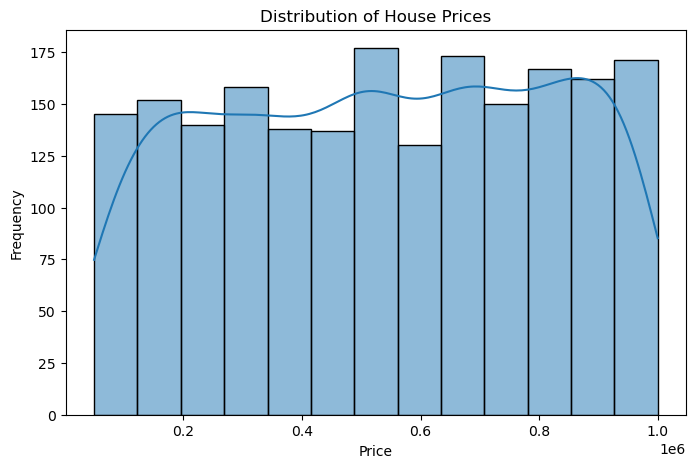

In [324]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 2. Area vs Price

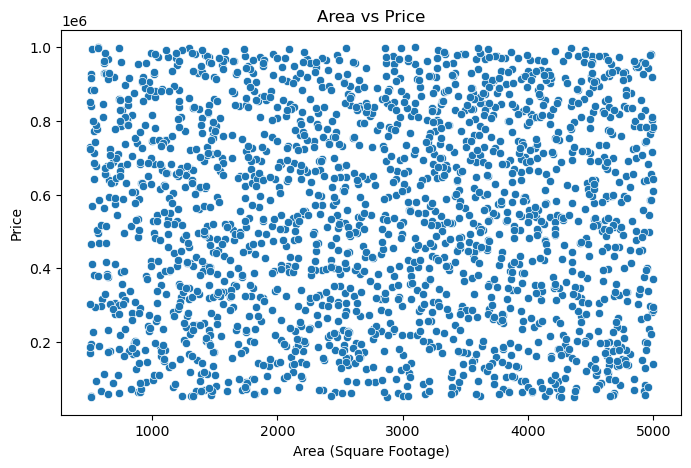

In [325]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title('Area vs Price')
plt.xlabel('Area (Square Footage)')
plt.ylabel('Price')
plt.show()

# 3. Bedrooms vs Price

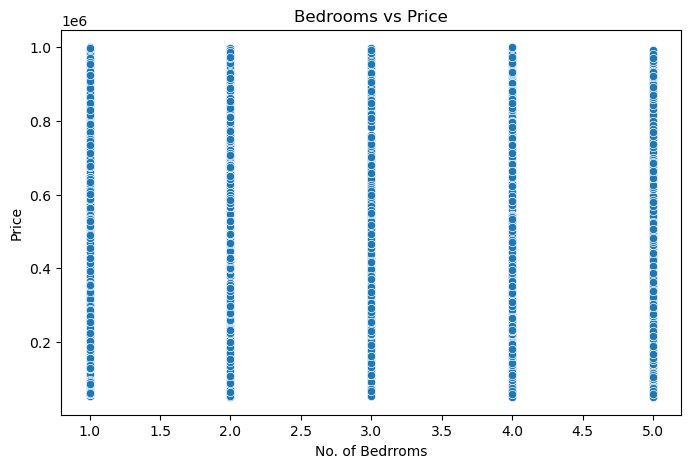

In [326]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Bedrooms'], y=df['Price'])
plt.title('Bedrooms vs Price')
plt.xlabel('No. of Bedrroms')
plt.ylabel('Price')
plt.show()

# 4. Bathrooms vs Price

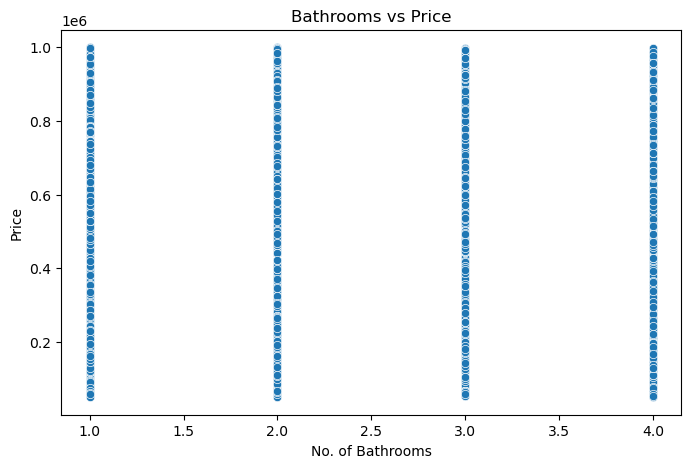

In [327]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Bathrooms'], y=df['Price'])
plt.title('Bathrooms vs Price')
plt.xlabel('No. of Bathrooms')
plt.ylabel('Price')
plt.show()

# 5. Correlation Heatmap

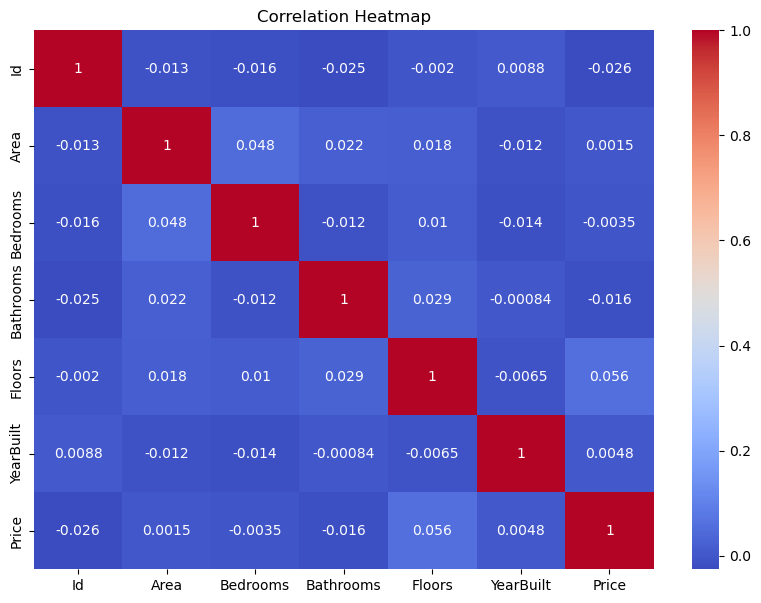

In [328]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Pairplot

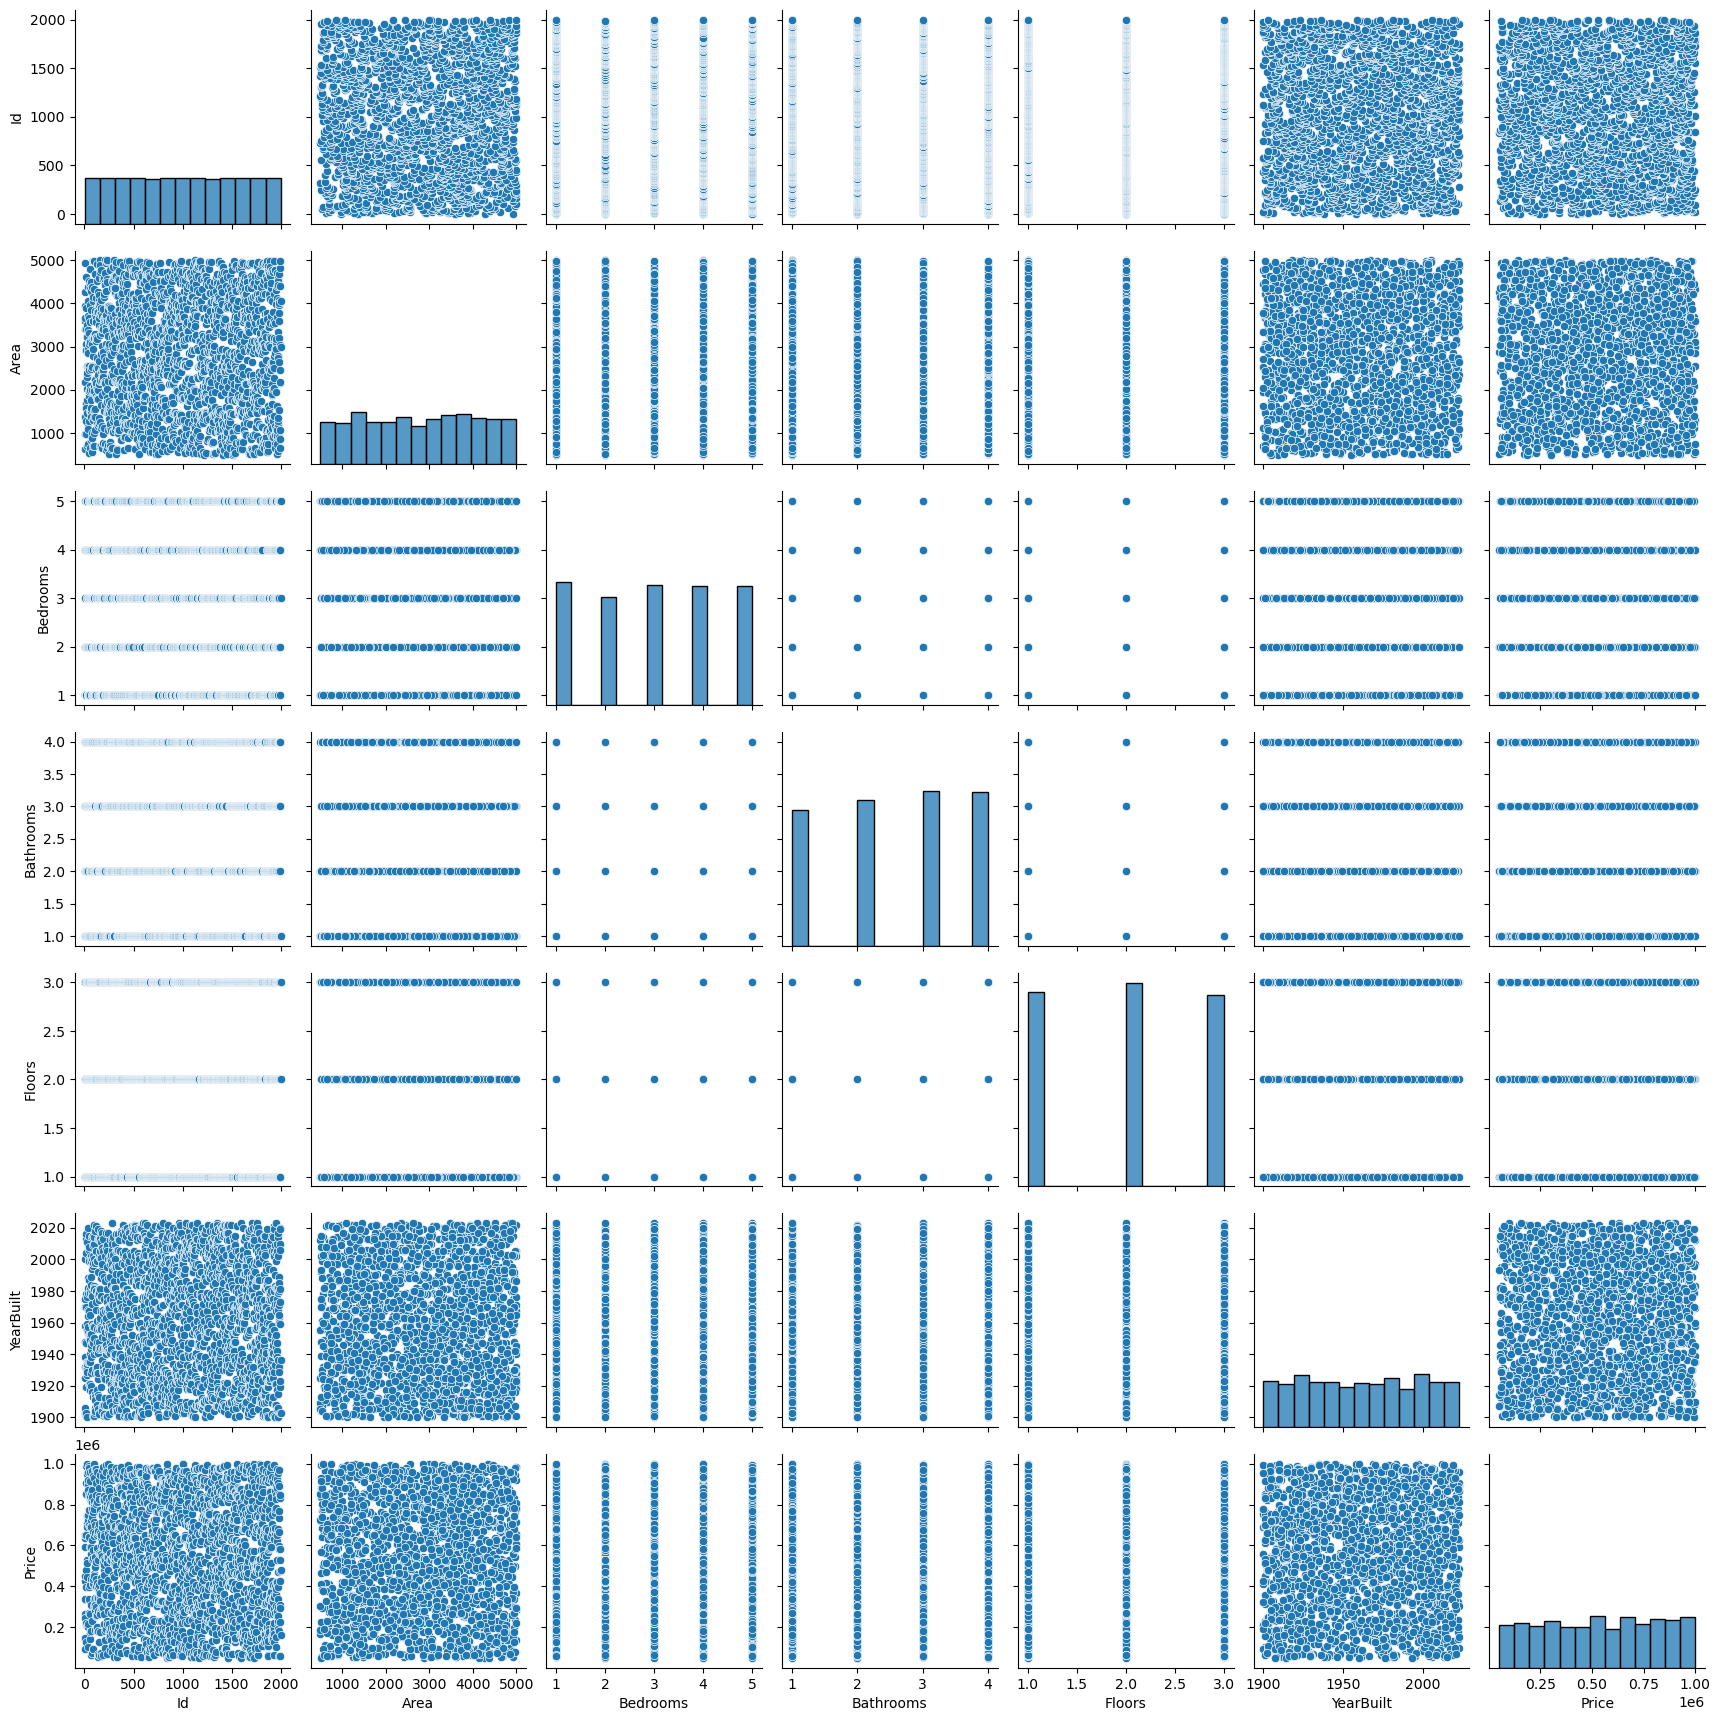

In [329]:
sns.pairplot(df)
plt.show()

## Feature Selection

In [330]:
y = df['Price']

In [331]:
X = df[['Area', 'Bedrooms', 'Bathrooms']]

## Train test split and Feature Scaling

In [332]:
from sklearn.preprocessing import StandardScaler
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model

In [333]:
# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

## Model Predictions

In [334]:
# Predict on test data
y_pred = model.predict(X_test)

print(y_pred[:5])

[522171.74062846 551143.21917408 522026.6322543  551321.92605739
 541453.78898837]


## Model Evaluation

In [335]:
## Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 243756.4797682511


In [336]:
## Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 78440549944.81049


In [337]:
## Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 280072.40125512274


## Regression Coefficients

In [338]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

     Feature  Coefficient
0       Area    -0.095410
1   Bedrooms   -13.259538
2  Bathrooms -9759.661183


## Actual vs Predicted Prices

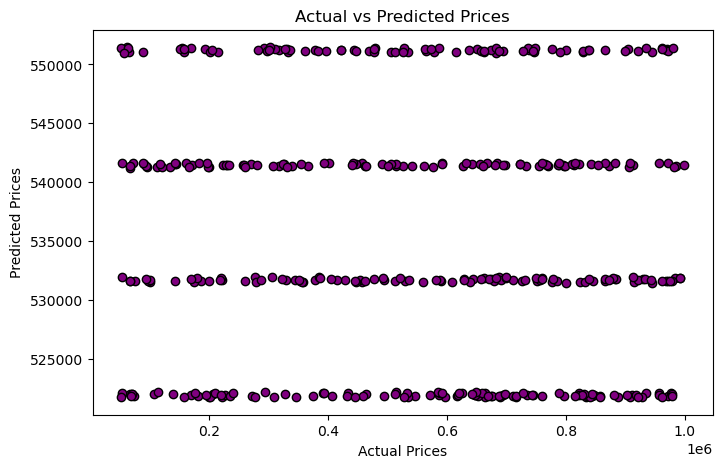

In [339]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred,color='purple', edgecolors='black', label='Predictions')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

## Residual Analysis

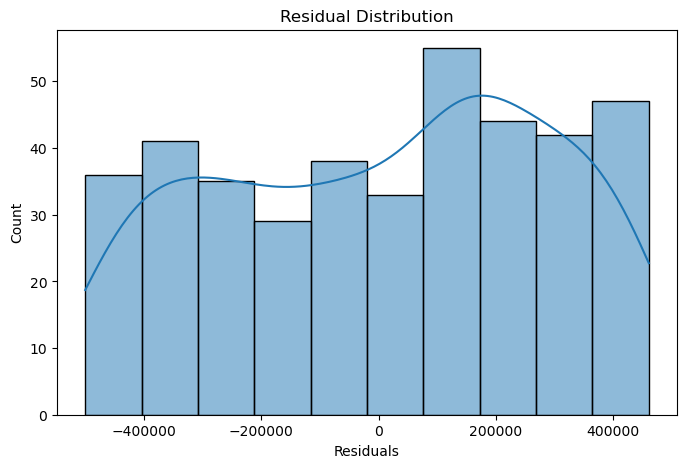

In [340]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.show()

## Predict Price for a New House

In [341]:
sample_house = [[2500, 4, 3]]

predicted_price = model.predict(sample_house)

print('Predicted House Price:', predicted_price[0])

Predicted House Price: 531713.4935543528
